# Estudio de Hiperparámetros

In [ ]:
# Carga de liberías
!pip install deap
from deap import creator, base, tools, algorithms
import random
import math
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 23.2 MB/s eta 0:00:00


In [ ]:
#Datos del problema

# Mapa de criticidad 10x10 (fila, columna)
CRITICIDAD = [
    [2,1,1,2,5,5,2,1,1,2],
    [5,4,4,4,4,4,4,4,4,5],
    [5,4,3,3,3,3,3,3,4,5],
    [2,4,3,2,2,2,2,3,4,2],
    [1,4,3,2,1,1,2,3,4,1],
    [1,4,3,2,1,1,2,3,4,1],
    [2,4,3,2,2,2,2,3,4,2],
    [5,4,3,3,3,3,3,3,4,5],
    [5,4,4,4,4,4,4,4,4,5],
    [2,1,1,2,5,5,2,1,1,2]
]

# Tabla maestra de sensores
# Índice 0 = no sensor, índices 1-4 = tipo de sensor
# tipo 1: Vibración  | tipo 2: Ultrasónico | tipo 3: Temperatura | tipo 4: Cámara visión
RADIO   = {1: 1.0,  2: 2.25,  3: 2.5,   4: 3.0  }  # en unidades de celda
COSTO   = {1: 200,  2: 450,   3: 1800,  4: 2500 }  # en USD
ENERGIA = {1: 0.16, 2: 1.2,   3: 2.5,   4: 6.5  }  # en Watts

COSTO_MAX   = max(COSTO.values())    # 2500
ENERGIA_MAX = max(ENERGIA.values())  # 6.5

In [ ]:
2#Entradas del usuario
def solicitar_posiciones():
    """
    Solicita al usuario las 15 posiciones candidatas para instalar sensores.
    Cada posición es una tupla (fila, columna) dentro de la cuadrícula 10x10.
    Valida que no se repitan y que estén dentro del rango válido.
    """
    print("=== INGRESO DE POSICIONES CANDIDATAS ===")
    print("Ingrese 15 posiciones en formato: fila,columna")
    print("Filas y columnas van de 0 a 9.")
    print("Ejemplo: 3,7\n")

    posiciones = []
    while len(posiciones) < 15:
        restantes = 15 - len(posiciones)
        try:
            entrada = input(f"Posición {len(posiciones)+1}/15 (faltan {restantes}): ").strip()
            fila, col = map(int, entrada.split(','))

            # Validar rango
            if not (0 <= fila <= 9 and 0 <= col <= 9):
                print("  Fuera de rango. Filas y columnas deben estar entre 0 y 9.")
                continue

            # Validar duplicados
            if (fila, col) in posiciones:
                print(f"  La posición ({fila},{col}) ya fue ingresada.")
                continue

            posiciones.append((fila, col))
            print(f"  Posición ({fila},{col}) agregada.")

        except ValueError:
            print("  Formato inválido. Use fila,columna (ej: 3,7).")

    print(f"\n15 posiciones ingresadas correctamente.\n")
    return posiciones

def solicitar_parametros():
    """
    Solicita los valores de n para presupuesto y energía.
    Estos determinan los límites máximos P_M y E_M.
    """
    print("=== INGRESO DE PARÁMETROS DE RESTRICCIÓN ===")

    while True:
        try:
            n_pres = float(input("Valor de n para presupuesto (P_M = n × 2500 USD): ")) # Se pone un minimo de 2500, ya que alcanza para 1 camara.
            if n_pres <= 0:
                print("  n debe ser mayor a 0.")
                continue
            break
        except ValueError:
            print("  Ingrese un número válido.")

    while True:
        try:
            n_en = float(input("Valor de n para energía   (E_M = n × 6.5 W):    "))
            if n_en <= 0:
                print("  n debe ser mayor a 0.")
                continue
            break
        except ValueError:
            print("  Ingrese un número válido.")

    P_M = n_pres * COSTO_MAX
    E_M = n_en   * ENERGIA_MAX

    print(f"\nPresupuesto máximo: ${P_M:,.0f} USD")
    print(f"Energía máxima:     {E_M:.1f} W\n")

    return P_M, E_M

POSICIONES_CANDIDATAS = solicitar_posiciones()
P_M, E_M = solicitar_parametros()

=== INGRESO DE POSICIONES CANDIDATAS ===
Ingrese 15 posiciones en formato: fila,columna
Filas y columnas van de 0 a 9.
Ejemplo: 3,7

Posición 1/15 (faltan 15): 0,0
  Posición (0,0) agregada.
Posición 2/15 (faltan 14): 0,9
  Posición (0,9) agregada.
Posición 3/15 (faltan 13): 2,4
  Posición (2,4) agregada.
Posición 4/15 (faltan 12): 2,5
  Posición (2,5) agregada.
Posición 5/15 (faltan 11): 4,2
  Posición (4,2) agregada.
Posición 6/15 (faltan 10): 4,7
  Posición (4,7) agregada.
Posición 7/15 (faltan 9): 5,2
  Posición (5,2) agregada.
Posición 8/15 (faltan 8): 5,7
  Posición (5,7) agregada.
Posición 9/15 (faltan 7): 7,4
  Posición (7,4) agregada.
Posición 10/15 (faltan 6): 7,5
  Posición (7,5) agregada.
Posición 11/15 (faltan 5): 9,0
  Posición (9,0) agregada.
Posición 12/15 (faltan 4): 9,9
  Posición (9,9) agregada.
Posición 13/15 (faltan 3): 3,1
  Posición (3,1) agregada.
Posición 14/15 (faltan 2): 6,8
  Posición (6,8) agregada.
Posición 15/15 (faltan 1): 1,6
  Posición (1,6) agregada.


In [ ]:
# FUNCIÓN DE EVALUACIÓN (fitness)
def evaluar(individuo):
    costo_total   = 0.0
    energia_total = 0.0
    penalizacion  = 0.0

    sensores_activos = []
    for idx, tipo in enumerate(individuo):
        if tipo != 0:
            sensores_activos.append((idx, tipo))
            costo_total   += COSTO[tipo]
            energia_total += ENERGIA[tipo]

    # Precalcular celdas cubiertas por cada sensor individualmente
    cobertura_por_sensor = {}
    for idx, tipo in sensores_activos:
        pos_sensor = POSICIONES_CANDIDATAS[idx]
        celdas = set()
        for fila in range(10):
            for col in range(10):
                distancia = math.sqrt(
                    (fila - pos_sensor[0])**2 + (col - pos_sensor[1])**2
                )
                if distancia <= RADIO[tipo]:
                    celdas.add((fila, col))
        cobertura_por_sensor[idx] = celdas

    # Cobertura ponderada — unión de todas las celdas cubiertas
    todas_cubiertas = set()
    for celdas in cobertura_por_sensor.values():
        todas_cubiertas |= celdas

    cobertura_ponderada = sum(
        CRITICIDAD[f][c] for (f, c) in todas_cubiertas
    )

    # Penalizar sensores redundantes usando operaciones de conjuntos
    for idx, tipo in sensores_activos:
        otras_celdas = set()
        for idx2, tipo2 in sensores_activos:
            if idx2 != idx:
                otras_celdas |= cobertura_por_sensor[idx2]
        # Si todas las celdas de este sensor ya están cubiertas por otros
        if cobertura_por_sensor[idx].issubset(otras_celdas):
            penalizacion += 500

    # Penalización por restricciones duras
    if costo_total > P_M:
        penalizacion += 1000 * (costo_total - P_M)
    if energia_total > E_M:
        penalizacion += 1000 * (energia_total - E_M)

    return [cobertura_ponderada - penalizacion]

In [ ]:
# DEFINICIÓN DEL TIPO FITNESS Y DEL INDIVIDUO (DEAP)

# Función de fitness: maximizar una única variable (peso positivo)
creator.create('FitnessSensor', base.Fitness, weights=(1.0,))

# Individuo: lista de 15 enteros con su función de fitness asociada
creator.create('Individuo', list, fitness=creator.FitnessSensor)

# TOOLBOX: atributos, individuo y población
# ============================================================

toolbox = base.Toolbox()

# Alelo: entero entre 0 y 4 (0=sin sensor, 1-4=tipo de sensor)
toolbox.register('alelo', random.randint, 0, 4) # Se usa randint porque no tenemos valores con decimales

# Individuo: lista de 15 alelos (uno por posición candidata)
toolbox.register('individuo_gen', tools.initRepeat,
                 creator.Individuo, toolbox.alelo, n=15)

# Población: lista de individuos
toolbox.register('Poblacion', tools.initRepeat,
                 list, toolbox.individuo_gen)

In [ ]:
# OPERADORES GENÉTICOS

toolbox.register('evaluate', evaluar)
toolbox.register('mate',     tools.cxTwoPoint)
toolbox.register('mutate',   tools.mutUniformInt, low=0, up=4, indpb=0.2)

def correr_evolutivo(popu_size, generations, mate_chance, mutate_chance,
                     tournsize, elitismo_puro=False, sel_random=False, verbose=True):
    """
    Corre el algoritmo evolutivo con los hiperparámetros dados.
    Retorna el Hall of Fame y el historial de estadísticas.

    Parámetros:
    - popu_size:      Tamaño de la población inicial
    - generations:    Número de generaciones
    - mate_chance:    Probabilidad de cruce entre dos individuos
    - mutate_chance:  Probabilidad de mutación de un individuo
    - elitismo_puro: Si True, selecciona siempre los mejores (selBest)
    - sel_random:    Si True, selecciona aleatoriamente sin considerar fitness (selRandom)
    - tournsize:     Tamaño del torneo (None si elitismo_puro o sel_random es True)
    - verbose:        Si True, imprime progreso por generación
    """

    # Registrar mecanismo de selección según parámetro
    if sel_random:
        # Selección aleatoria pura: ignora completamente el fitness
        toolbox.register('select', tools.selRandom)
    elif elitismo_puro:
        # Elitismo puro: siempre selecciona los mejores individuos como padres
        toolbox.register('select', tools.selBest)
    else:
        # Torneo: compiten grupos aleatorios de tournsize individuos
        toolbox.register('select', tools.selTournament, tournsize=tournsize)

    poblacion = toolbox.Poblacion(n=popu_size)
    hof = tools.HallOfFame(5)

    historial_max = []
    historial_avg = []
    historial_min = []
    historial_std = []

    for gen in range(generations):

        # --- 1. EVALUACIÓN ---
        invalidos = [ind for ind in poblacion if not ind.fitness.valid]
        for ind in invalidos:
            ind.fitness.values = toolbox.evaluate(ind)

        # --- 2. ESTADÍSTICAS ---
        fits = [ind.fitness.values[0] for ind in poblacion]
        historial_avg.append(np.mean(fits))
        historial_min.append(min(fits))

        fits_factibles = [f for f in fits if f > 0]
        if len(fits_factibles) > 1:
            historial_std.append(np.std(fits_factibles))
        else:
            historial_std.append(0)

        hof.update(poblacion)
        historial_max.append(hof[0].fitness.values[0])

        if verbose and gen % 10 == 0:
            print(f"  Gen {gen:3d}: Mejor histórico={hof[0].fitness.values[0]:.2f} | "
                  f"Avg={np.mean(fits):.2f} | Std={historial_std[-1]:.2f}")

        # --- 3. SELECCIÓN ---
        padres = list(toolbox.select(poblacion, len(poblacion)))

        # --- 4. CRUCE ---
        hijos = []
        for i in range(0, len(padres) - 1, 2):
            hijo1 = toolbox.clone(padres[i])
            hijo2 = toolbox.clone(padres[i + 1])
            if random.random() < mate_chance:
                toolbox.mate(hijo1, hijo2)
                del hijo1.fitness.values
                del hijo2.fitness.values
            hijos.extend([hijo1, hijo2])

        # --- 5. MUTACIÓN ---
        for hijo in hijos:
            if random.random() < mutate_chance:
                toolbox.mutate(hijo)
                del hijo.fitness.values

        # --- 6. REEMPLAZO ---
        poblacion[:] = hijos

    # Evaluación final
    for ind in poblacion:
        if not ind.fitness.valid:
            ind.fitness.values = toolbox.evaluate(ind)
    hof.update(poblacion)

    return hof, historial_max, historial_avg, historial_min, historial_std

In [ ]:
def grafica_interactiva(datos, key, titulo, ylabel, ylim=None):
    fig, ax = plt.subplots(figsize=(10, 4))

    lineas = []
    for etiqueta, res in datos.items():
        linea, = ax.plot(res[key], label=str(etiqueta))
        lineas.append(linea)

    ax.set_xlabel('Generación')
    ax.set_ylabel(ylabel)
    ax.set_title(titulo)
    if ylim:
        ax.set_ylim(ylim)
    ax.grid(True, alpha=0.3)

    legend = ax.legend()

    map_label_linea = {}
    for legend_linea, linea in zip(legend.get_lines(), lineas):
        legend_linea.set_picker(True)
        legend_linea.set_pickradius(7)
        map_label_linea[legend_linea] = linea

    def al_hacer_clic(event):
        legend_linea = event.artist
        if legend_linea in map_label_linea:
            linea = map_label_linea[legend_linea]
            visible = not linea.get_visible()
            linea.set_visible(visible)
            legend_linea.set_alpha(1.0 if visible else 0.3)
            fig.canvas.draw()

    fig.canvas.mpl_connect('pick_event', al_hacer_clic)
    plt.tight_layout()
    plt.show(block=True)  # block=True es clave en scripts .py

In [ ]:
def visualizar_solucion(mejor, posiciones_candidatas, criticidad, radio, costo, energia, P_M, E_M):

    sensores_activos = [(idx, tipo) for idx, tipo in enumerate(mejor) if tipo != 0]

    # Calcular celdas cubiertas
    celdas_cubiertas = {}  # (fila, col) -> tipo de sensor que la cubre
    for fila in range(10):
        for col in range(10):
            for idx, tipo in sensores_activos:
                pos_sensor = posiciones_candidatas[idx]
                distancia = math.sqrt(
                    (fila - pos_sensor[0])**2 + (col - pos_sensor[1])**2
                )
                if distancia <= RADIO[tipo]:
                    celdas_cubiertas[(fila, col)] = tipo
                    break

    fig, ax = plt.subplots(figsize=(10, 10))

    # --- Mapa de criticidad como fondo ---
    criticidad_array = np.array(criticidad, dtype=float)
    cmap_criticidad = plt.cm.YlOrRd
    im = ax.imshow(criticidad_array, cmap=cmap_criticidad, vmin=1, vmax=5,
                   alpha=0.6, origin='upper')
    plt.colorbar(im, ax=ax, label='Nivel de criticidad', shrink=0.8)

    # --- Marcar celdas NO cubiertas con X ---
    for fila in range(10):
        for col in range(10):
            if (fila, col) not in celdas_cubiertas:
                ax.text(col, fila, '✗', ha='center', va='center',
                        fontsize=14, color='black', fontweight='bold')

    # --- Dibujar radios de cobertura ---
    COLORES_SENSOR = {
        1: 'blue',    # Vibración
        2: 'green',   # Ultrasónico
        3: 'purple',  # Temperatura
        4: 'cyan'     # Cámara
    }

    for idx, tipo in sensores_activos:
        pos = posiciones_candidatas[idx]
        fila, col = pos
        radio_sensor = RADIO[tipo]
        color = COLORES_SENSOR[tipo]

        # Círculo de cobertura
        circulo = plt.Circle((col, fila), radio_sensor,
                              color=color, fill=False,
                              linewidth=1.5, linestyle='--', alpha=0.5)
        ax.add_patch(circulo)

    # --- Marcar posiciones candidatas sin sensor ---
    for idx, pos in enumerate(posiciones_candidatas):
        fila, col = pos
        tipo = mejor[idx]
        if tipo == 0:
            ax.plot(col, fila, 's', color='gray', markersize=12,
                    markeredgecolor='black', markeredgewidth=1, alpha=0.5)
            ax.text(col, fila, 'X', ha='center', va='center',
                    fontsize=8, color='black')

# --- Marcar sensores activos ---
    NOMBRES_CORTOS = {1: 'Vib', 2: 'Ult', 3: 'Tmp', 4: 'Cam'}

    for idx, tipo in sensores_activos:
        pos = posiciones_candidatas[idx]
        fila, col = pos
        color = COLORES_SENSOR[tipo]

        ax.plot(col, fila, 'o', color=color, markersize=16,
                markeredgecolor='black', markeredgewidth=1.5, zorder=5)
        ax.text(col, fila, NOMBRES_CORTOS[tipo], ha='center', va='center',
                fontsize=7, color='white', fontweight='bold', zorder=6)

    # --- Cuadrícula ---
    ax.set_xticks(np.arange(-0.5, 10, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, 10, 1), minor=True)
    ax.grid(which='minor', color='gray', linewidth=0.5)
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))
    ax.set_xticklabels(range(10))
    ax.set_yticklabels(range(10))

    # --- Leyenda ---
    leyenda = [
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue',
                   markersize=10, label='Vibración (VSA001)'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='green',
                   markersize=10, label='Ultrasónico (UM30-214113)'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='purple',
                   markersize=10, label='Temperatura (Xi80)'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='cyan',
                   markersize=10, label='Cámara visión (In-Sight 8000)'),
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='gray',
                   markersize=10, label='Posición sin sensor'),
        plt.Line2D([0], [0], marker='x', color='black',
                   markersize=10, label='Celda no cubierta'),
    ]
    ax.legend(handles=leyenda, loc='upper left', bbox_to_anchor=(1.15, 1))

    costo_total   = sum(COSTO[t]   for _, t in sensores_activos)
    energia_total = sum(ENERGIA[t] for _, t in sensores_activos)
    cobertura     = sum(criticidad[f][c] for (f, c) in celdas_cubiertas)
    total_crit    = sum(sum(f) for f in criticidad)

    ax.set_title(
        f'Configuración óptima de sensores\n'
        f'Cobertura: {cobertura}/{total_crit} ({100*cobertura/total_crit:.1f}%) | '
        f'Costo: ${costo_total:,} / ${P_M:,} | '
        f'Energía: {energia_total:.1f}W / {E_M:.1f}W',
        fontsize=11
    )

    ax.set_xlim(-0.5, 9.5)
    ax.set_ylim(9.5, -0.5)
    plt.tight_layout()
    plt.show(block=True)


In [ ]:
# --- Experimento 1 ---
print("=== EXPERIMENTO 1: TAMAÑO DE POBLACIÓN ===\n")
poblaciones_a_probar = [25, 50, 75, 100, 125, 150]
resultados_poblacion = {}

for tam in poblaciones_a_probar:
    print(f"Corriendo con popu_size={tam}...")
    hof, h_max, h_avg, h_min, h_std = correr_evolutivo(
        popu_size=tam, generations=100, mate_chance=0.7,
        mutate_chance=0.3, tournsize=3, verbose=False
    )
    resultados_poblacion[tam] = {
        'hof': hof, 'max': h_max, 'avg': h_avg,
        'min': h_min, 'std': h_std,
        'mejor_fitness': hof[0].fitness.values[0]
    }
    print(f"  Mejor fitness: {hof[0].fitness.values[0]:.2f}\n")

print("\n=== GENERACIÓN EN QUE ALCANZÓ EL ÓPTIMO ===")
for tam, res in resultados_poblacion.items():
    optimo = max(res['max'])
    gen_optimo = next(i for i, v in enumerate(res['max']) if v == optimo)
    print(f"  popu_size={tam}: alcanzó {optimo:.0f} en generación {gen_optimo}")

grafica_interactiva(resultados_poblacion, 'max',
                    'Experimento 1: Mejor fitness — Tamaño de población',
                    'Mejor fitness', ylim=(0, 320))

grafica_interactiva(resultados_poblacion, 'std',
                    'Experimento 1: Diversidad — Tamaño de población',
                    'Desviación estándar')

print("\n=== ANÁLISIS DE DIVERSIDAD PROMEDIO — TAMAÑO DE POBLACIÓN ===")
for tam, res in resultados_poblacion.items():
    std_promedio = np.mean(res['std'])
    std_estabilidad = np.std(res['std'])
    print(f"  popu_size={tam}: std_promedio={std_promedio:.2f} | variabilidad_curva={std_estabilidad:.2f}")

In [ ]:
# --- Experimento 2: Tasa de mutación ---
print("=== EXPERIMENTO 2: TASA DE MUTACIÓN ===\n")

mutaciones_a_probar = [0.01, 0.02, 0.05, 0.3, 0.8]
resultados_mutacion = {}

for mut in mutaciones_a_probar:
    print(f"Corriendo con mutate_chance={mut}...")
    hof, h_max, h_avg, h_min, h_std = correr_evolutivo(
        popu_size=75, generations=100, mate_chance=0.7,
        mutate_chance=mut, tournsize=3, verbose=False
    )
    resultados_mutacion[mut] = {
        'max': h_max, 'avg': h_avg, 'std': h_std,
        'mejor_fitness': hof[0].fitness.values[0]
    }
    print(f"  Mejor fitness: {hof[0].fitness.values[0]:.2f}\n")

print("\n=== GENERACIÓN EN QUE ALCANZÓ EL ÓPTIMO ===")
for mut, res in resultados_mutacion.items():
    optimo = max(res['max'])
    gen_optimo = next(i for i, v in enumerate(res['max']) if v == optimo)
    print(f"  mutate_chance={mut}: alcanzó {optimo:.0f} en generación {gen_optimo}")

grafica_interactiva(resultados_mutacion, 'max',
                    'Experimento 2: Mejor fitness — Tasa de mutación',
                    'Mejor fitness', ylim=(0, 320))

grafica_interactiva(resultados_mutacion, 'std',
                    'Experimento 2: Diversidad — Tasa de mutación',
                    'Desviación estándar')

print("\n=== ANÁLISIS DE DIVERSIDAD PROMEDIO — TASA DE MUTACIÓN ===")
for mut, res in resultados_mutacion.items():
    std_promedio = np.mean(res['std'])
    std_estabilidad = np.std(res['std'])
    print(f"  mutate_chance={mut}: std_promedio={std_promedio:.2f} | variabilidad_curva={std_estabilidad:.2f}")

In [ ]:
# --- Experimento 3: Mecanismo de selección ---
print("=== EXPERIMENTO 3: MECANISMO DE SELECCIÓN ===\n")

configuraciones_seleccion = {
    'aleatorio puro (selRandom)':   {'tournsize': None, 'elitismo_puro': False, 'sel_random': True},
    'tournsize=2':                  {'tournsize': 2,  'elitismo_puro': False, 'sel_random': False},
    'tournsize=3':                  {'tournsize': 3,  'elitismo_puro': False, 'sel_random': False},
    'elitismo puro (selBest)':      {'tournsize': None,'elitismo_puro': True, 'sel_random': False},
}

resultados_seleccion = {}

for nombre, config in configuraciones_seleccion.items():
    print(f"Corriendo con {nombre}...")
    hof, h_max, h_avg, h_min, h_std = correr_evolutivo(
        popu_size=75, generations=100, mate_chance=0.7,
        mutate_chance=0.3, tournsize=config['tournsize'],
        elitismo_puro=config['elitismo_puro'], sel_random=config['sel_random'], verbose=False
    )
    resultados_seleccion[nombre] = {
        'max': h_max, 'avg': h_avg, 'std': h_std,
        'mejor_fitness': hof[0].fitness.values[0]
    }
    print(f"  Mejor fitness: {hof[0].fitness.values[0]:.2f}\n")

print("\n=== GENERACIÓN EN QUE ALCANZÓ EL ÓPTIMO ===")
for nombre, res in resultados_seleccion.items():
    optimo = max(res['max'])
    gen_optimo = next(i for i, v in enumerate(res['max']) if v == optimo)
    print(f"  {nombre}: alcanzó {optimo:.0f} en generación {gen_optimo}")

grafica_interactiva(resultados_seleccion, 'max',
                    'Experimento 3: Calidad — Mecanismo de selección',
                    'Mejor fitness', ylim=(0, 320))

grafica_interactiva(resultados_seleccion, 'std',
                    'Experimento 3: Diversidad — Mecanismo de selección',
                    'Desviación estándar')

print("\n=== ANÁLISIS DE DIVERSIDAD PROMEDIO — MECANISMO DE SELECCIÓN ===")
for nombre, res in resultados_seleccion.items():
    std_promedio = np.mean(res['std'])
    std_estabilidad = np.std(res['std'])
    print(f"  {nombre}: std_promedio={std_promedio:.2f} | variabilidad_curva={std_estabilidad:.2f}")

# Modelo final y resultados


In [ ]:
ESCENARIOS_CRITICIDAD = {
    'Escenario 1 - Bordes críticos': [
        [2,1,1,2,5,5,2,1,1,2],
        [5,4,4,4,4,4,4,4,4,5],
        [5,4,3,3,3,3,3,3,4,5],
        [2,4,3,2,2,2,2,3,4,2],
        [1,4,3,2,1,1,2,3,4,1],
        [1,4,3,2,1,1,2,3,4,1],
        [2,4,3,2,2,2,2,3,4,2],
        [5,4,3,3,3,3,3,3,4,5],
        [5,4,4,4,4,4,4,4,4,5],
        [2,1,1,2,5,5,2,1,1,2]
    ],
    'Escenario 2 - Centro crítico': [
        [1,1,1,1,1,1,1,1,1,1],
        [1,2,2,2,2,2,2,2,2,1],
        [1,2,3,3,3,3,3,3,2,1],
        [1,2,3,4,4,4,4,3,2,1],
        [1,2,3,4,5,5,5,4,3,1],
        [1,2,3,4,5,5,5,4,3,1],
        [1,2,3,4,5,5,4,4,3,1],
        [1,2,3,4,4,4,4,3,2,1],
        [1,2,2,2,2,2,2,2,2,1],
        [1,1,1,1,1,1,1,1,1,1]
    ],
    'Escenario 3 - Zonas dispersas': [
        [5,1,1,2,5,1,1,2,1,5],
        [1,2,1,1,1,1,1,1,2,1],
        [1,1,5,4,1,1,4,5,1,1],
        [2,1,4,1,1,1,1,4,1,2],
        [5,1,1,1,3,3,1,1,1,5],
        [5,1,1,1,3,3,1,1,1,5],
        [2,1,4,1,1,1,1,4,1,2],
        [1,1,5,4,1,1,4,5,1,1],
        [1,2,1,1,1,1,1,1,2,1],
        [5,1,1,2,5,1,1,2,1,5]
    ]
}

In [ ]:
def mostrar_resultados(hof_final, h_max_final, nombre_escenario):
    """
    Muestra los resultados completos de una corrida del evolutivo.
    """
    mejor = hof_final[0]

    NOMBRES_SENSOR = {
        0: 'Sin sensor',
        1: 'Vibración (VSA001)',
        2: 'Ultrasónico (UM30-214113)',
        3: 'Temperatura (Xi80)',
        4: 'Cámara visión (In-Sight 8000)'
    }

    sensores_activos = [(idx, tipo) for idx, tipo in enumerate(mejor) if tipo != 0]
    costo_total      = sum(COSTO[tipo]   for _, tipo in sensores_activos)
    energia_total    = sum(ENERGIA[tipo] for _, tipo in sensores_activos)
    n_sensores       = len(sensores_activos)

    cobertura_ponderada = 0.0
    celdas_cubiertas = []
    for fila in range(10):
        for col in range(10):
            for idx, tipo in sensores_activos:
                pos_sensor = POSICIONES_CANDIDATAS[idx]
                distancia = math.sqrt(
                    (fila - pos_sensor[0])**2 + (col - pos_sensor[1])**2
                )
                if distancia <= RADIO[tipo]:
                    cobertura_ponderada += CRITICIDAD[fila][col]
                    celdas_cubiertas.append((fila, col))
                    break

    criticidad_total     = sum(sum(fila) for fila in CRITICIDAD)
    porcentaje_cobertura = (cobertura_ponderada / criticidad_total) * 100

    print("\n" + "="*55)
    print(f"  RESULTADOS — {nombre_escenario}")
    print("="*55)

    print(f"\n{'POSICIÓN':<12} {'SENSOR':<35} {'COSTO':>10} {'ENERGÍA':>10}")
    print("-"*55)
    for idx, tipo in sensores_activos:
        pos = POSICIONES_CANDIDATAS[idx]
        print(f"{str(pos):<12} {NOMBRES_SENSOR[tipo]:<35} "
              f"${COSTO[tipo]:>8,} {ENERGIA[tipo]:>9.2f}W")

    print("-"*55)
    print(f"\n  Sensores activos:      {n_sensores} de 15 posiciones")
    print(f"  Costo total:           ${costo_total:,.0f} USD "
          f"({'OK' if costo_total <= P_M else 'EXCEDE PRESUPUESTO'})"
          f" — límite: ${P_M:,.0f}")
    print(f"  Energía total:         {energia_total:.2f} W "
          f"({'OK' if energia_total <= E_M else 'EXCEDE LÍMITE'}"
          f") — límite: {E_M:.1f} W")
    print(f"  Cobertura ponderada:   {cobertura_ponderada:.0f} / {criticidad_total} "
          f"({porcentaje_cobertura:.1f}%)")
    print(f"  Fitness obtenido:      {mejor.fitness.values[0]:.2f}")

    print(f"\n--- CELDAS NO CUBIERTAS ---")
    total_no_cubierto = 0
    for fila in range(10):
        for col in range(10):
            if (fila, col) not in celdas_cubiertas:
                print(f"  Celda ({fila},{col}) — criticidad {CRITICIDAD[fila][col]}")
                total_no_cubierto += CRITICIDAD[fila][col]
    print(f"  Criticidad no cubierta: {total_no_cubierto}")

    grafica_interactiva({'Modelo final': {'max': h_max_final}},
                        'max',
                        f'Convergencia — {nombre_escenario}',
                        'Mejor fitness', ylim=(0, 320))

    visualizar_solucion(mejor, POSICIONES_CANDIDATAS, CRITICIDAD,
                        RADIO, COSTO, ENERGIA, P_M, E_M)


  CORRIENDO: Escenario 1 - Bordes críticos


  RESULTADOS — Escenario 1 - Bordes críticos

POSICIÓN     SENSOR                                   COSTO    ENERGÍA
-------------------------------------------------------
(0, 0)       Ultrasónico (UM30-214113)           $     450      1.20W
(0, 9)       Temperatura (Xi80)                  $   1,800      2.50W
(2, 4)       Ultrasónico (UM30-214113)           $     450      1.20W
(4, 7)       Ultrasónico (UM30-214113)           $     450      1.20W
(5, 2)       Ultrasónico (UM30-214113)           $     450      1.20W
(7, 4)       Temperatura (Xi80)                  $   1,800      2.50W
(7, 5)       Ultrasónico (UM30-214113)           $     450      1.20W
(9, 0)       Ultrasónico (UM30-214113)           $     450      1.20W
(9, 9)       Ultrasónico (UM30-214113)           $     450      1.20W
(3, 1)       Ultrasónico (UM30-214113)           $     450      1.20W
(6, 8)       Temperatura (Xi80)                  $   1,800      2.50W
(1, 6)     

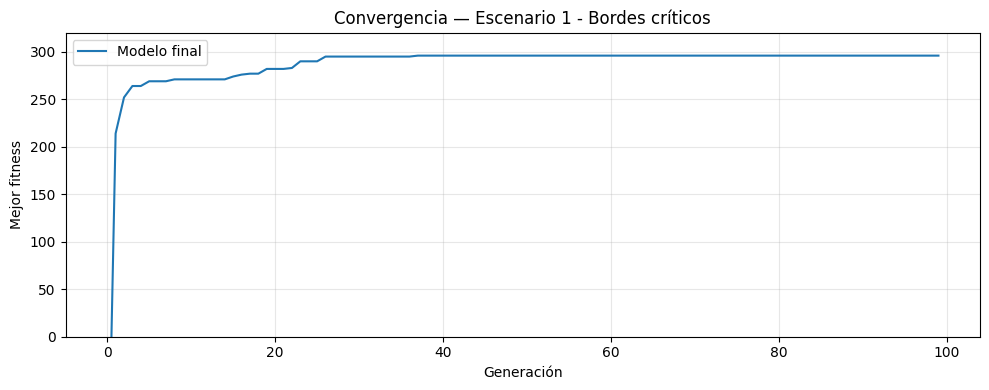

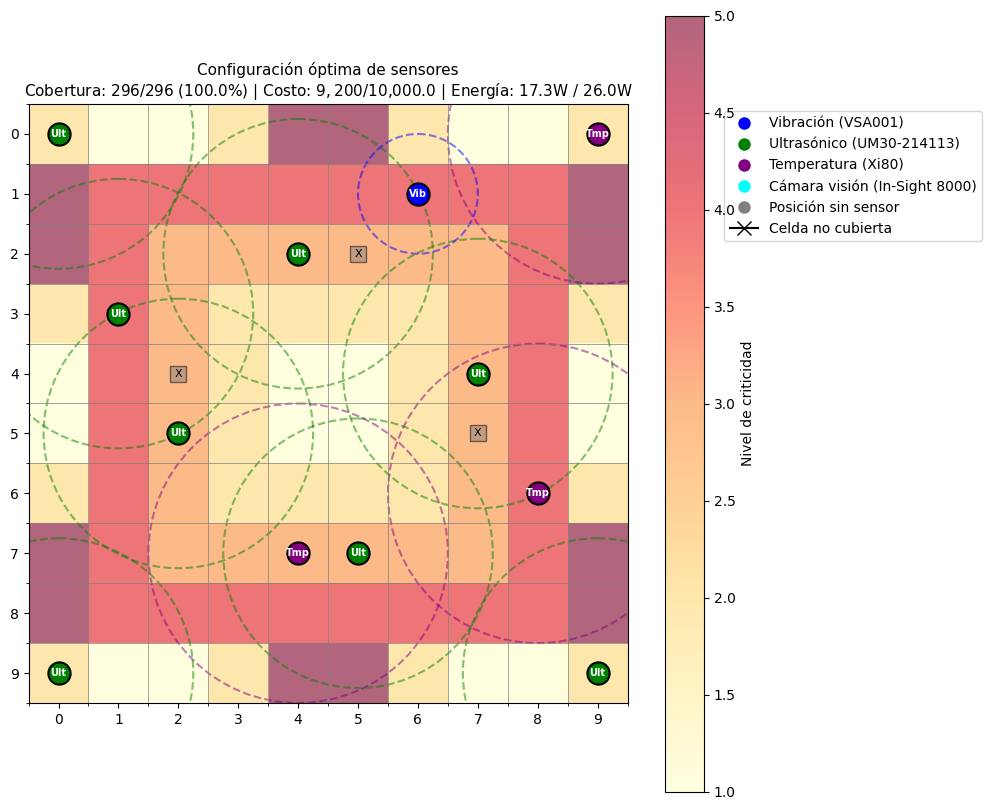


  CORRIENDO: Escenario 2 - Centro crítico


  RESULTADOS — Escenario 2 - Centro crítico

POSICIÓN     SENSOR                                   COSTO    ENERGÍA
-------------------------------------------------------
(0, 0)       Ultrasónico (UM30-214113)           $     450      1.20W
(0, 9)       Ultrasónico (UM30-214113)           $     450      1.20W
(2, 4)       Ultrasónico (UM30-214113)           $     450      1.20W
(4, 7)       Cámara visión (In-Sight 8000)       $   2,500      6.50W
(5, 2)       Ultrasónico (UM30-214113)           $     450      1.20W
(7, 4)       Ultrasónico (UM30-214113)           $     450      1.20W
(7, 5)       Ultrasónico (UM30-214113)           $     450      1.20W
(9, 0)       Ultrasónico (UM30-214113)           $     450      1.20W
(9, 9)       Ultrasónico (UM30-214113)           $     450      1.20W
(3, 1)       Ultrasónico (UM30-214113)           $     450      1.20W
(1, 6)       Temperatura (Xi80)                  $   1,800      2.50W
-------------

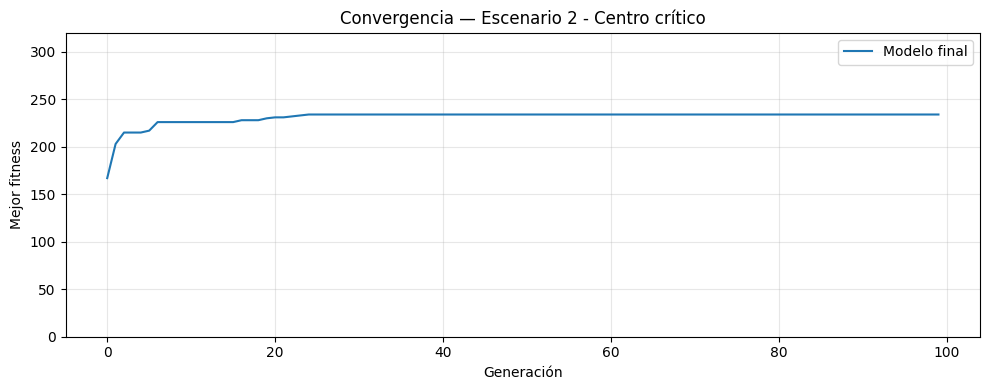

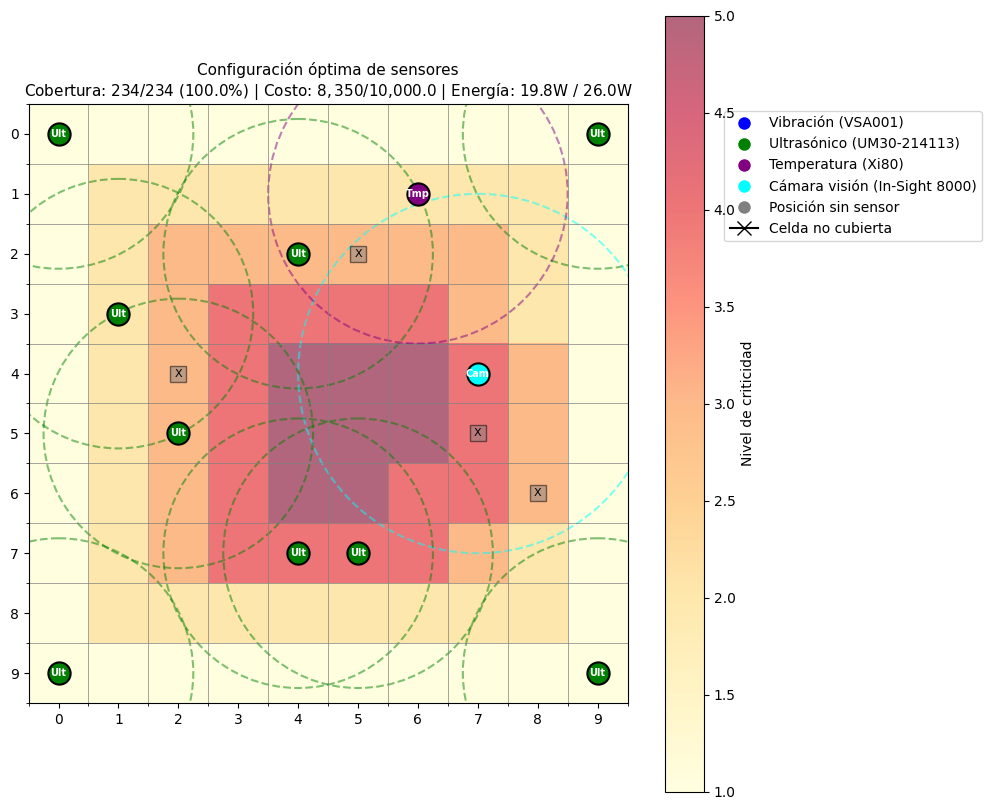


  CORRIENDO: Escenario 3 - Zonas dispersas


  RESULTADOS — Escenario 3 - Zonas dispersas

POSICIÓN     SENSOR                                   COSTO    ENERGÍA
-------------------------------------------------------
(0, 0)       Temperatura (Xi80)                  $   1,800      2.50W
(0, 9)       Ultrasónico (UM30-214113)           $     450      1.20W
(2, 4)       Ultrasónico (UM30-214113)           $     450      1.20W
(4, 2)       Ultrasónico (UM30-214113)           $     450      1.20W
(4, 7)       Ultrasónico (UM30-214113)           $     450      1.20W
(5, 2)       Ultrasónico (UM30-214113)           $     450      1.20W
(7, 5)       Cámara visión (In-Sight 8000)       $   2,500      6.50W
(9, 0)       Ultrasónico (UM30-214113)           $     450      1.20W
(9, 9)       Ultrasónico (UM30-214113)           $     450      1.20W
(6, 8)       Ultrasónico (UM30-214113)           $     450      1.20W
(1, 6)       Ultrasónico (UM30-214113)           $     450      1.20W
-----------

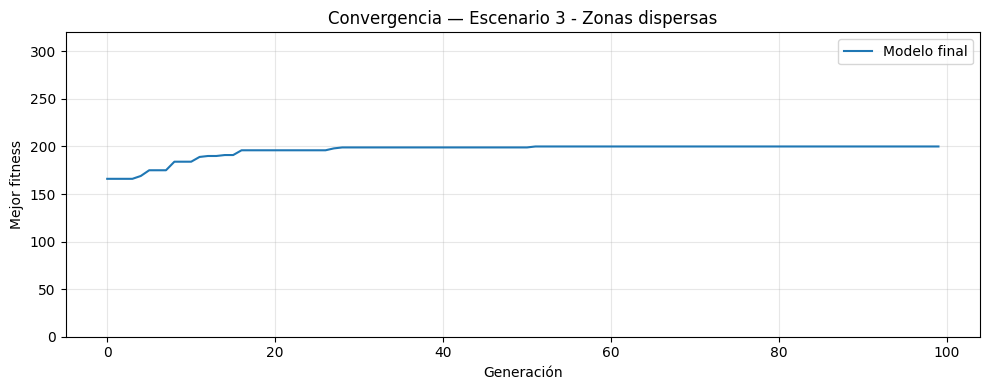

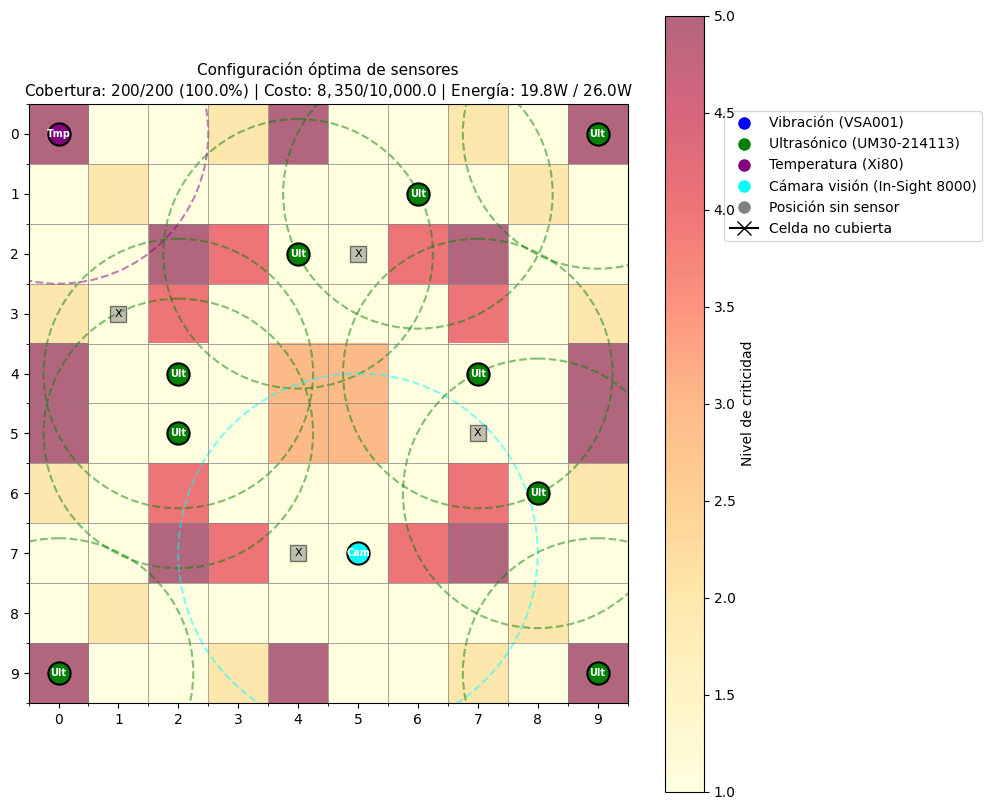

In [ ]:
for nombre_escenario, mapa_criticidad in ESCENARIOS_CRITICIDAD.items():
    print(f"\n{'='*55}")
    print(f"  CORRIENDO: {nombre_escenario}")
    print(f"{'='*55}\n")

    CRITICIDAD = mapa_criticidad

    hof_final, h_max_final, h_avg_final, h_min_final, h_std_final = correr_evolutivo(
        popu_size     = 75,
        generations   = 100,
        mate_chance   = 0.7,
        mutate_chance = 0.3,
        tournsize     = 3,
        elitismo_puro = False,
        sel_random    = False,
        verbose       = False
    )

    mostrar_resultados(hof_final, h_max_final, nombre_escenario)